In [54]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
import sys
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
project_root = Path.cwd().resolve().parents[2]
sys.path.append(str(project_root))

from defs.vae.ae import *
from defs.vae.training_defs import *

In [56]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

spectra, fractions = load_spectral_data()
# train_loader, val_loader = get_dataloaders(spectra, fractions)
unbatched_data = get_dataloader_unbatched(spectra, fractions)
num_spectra = unbatched_data.dataset[0][0].size(0)
print(unbatched_data.batch_size)
print(num_spectra)

Device: cpu
1
210


In [57]:
convolution = ConvEncoder([unbatched_data.batch_size, 32, 32], [128, 128], c_d={'pad': 1}, num_spectra=num_spectra)
criterion = nn.MSELoss()
optimizer = optim.Adam(convolution.parameters(), lr=1e-3)

# print(convolution.encoder)
# print(convolution.decoder)

n_epochs = 10

In [58]:
losses = []
for epoch in range(1, n_epochs+1):
    convolution.train()
    tot_loss = 0
    for xb, yb in unbatched_data:
        xb = xb.to(device)
        optimizer.zero_grad()
        loss_pred = criterion(convolution(xb), xb)
        loss_pred.backward()
        optimizer.step()

        tot_loss += float(loss_pred)

    losses.append(tot_loss / len(unbatched_data.dataset))

print(losses)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1, 210])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


[0.0125825902724731, 0.011626075577851357, 0.011585116974267031, 0.011569013225028991, 0.011612326567847978, 0.01163835375705162, 0.011553834158165334, 0.011553957624958469, 0.011513074018887893, 0.011535294733983986]


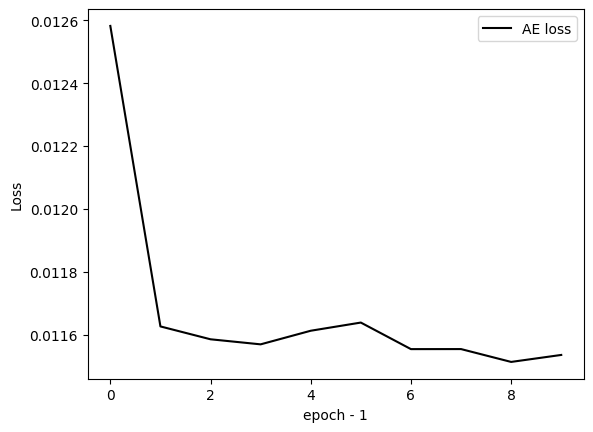

In [59]:
plt.plot(losses, color='black', label='AE loss')
plt.xlabel('epoch - 1'); plt.ylabel('Loss'); plt.legend()